In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import matplotlib.ticker as mticker

def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu_t = X_t.mean().values
    mu_tk = X_tk.mean().values

    Xc_t = X_t.values - mu_t
    Xc_tk = X_tk.values - mu_tk

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    std_t = X_t.std(ddof=0).values
    std_tk = X_tk.std(ddof=0).values

    # Avoid division by zero
    std_t[std_t == 0] = 1e-8
    std_tk[std_tk == 0] = 1e-8

    return Sigma_k / np.outer(std_tk, std_t)

k_values = [5]

In [4]:
def out_of_sample_lead_lag(n_months: int):
    years = range(2014, 2025)
    centralities = ["central", "peripheral"]
    portfolios = {}
    market_returns_dict = {}

    # 1. Load Data & Calculate Market Return
    for year in years:
        end_date = (
            pd.Timestamp(year=year + 1, month=n_months, day=1)
            + pd.offsets.MonthEnd(0)
        )
        path_ret = f"../../data/02_clean/returns_new_{year + 1}.parquet"
        full_ret = pd.read_parquet(path_ret).loc[:end_date]
        
        # Log market return for the OOS period
        market_returns_dict[year] = np.log1p(full_ret).mean(axis=1)
        
        for centrality in centralities:
            for k in k_values:
                path_csv = f"../../data/06_portfolios/{centrality}_{year}_{k}.csv"
                cols = pd.read_csv(path_csv, index_col="Date").columns.tolist()
                
                # Keep only valid columns
                valid_cols = [c for c in cols if c in full_ret.columns]
                portfolios[f"{centrality}_{year}_{k}"] = full_ret[valid_cols]

    # 2. Resample Returns to Excess Returns (Equal Weighting)
    weekly_returns = {}
    daily_returns = {}
    weekly2_returns = {}
    monthly_returns = {}
    
    for name, portfolio in portfolios.items():
        year = int(name.split("_")[1])
        log_returns = np.log1p(portfolio)
        R_m = market_returns_dict[year]
        
        tickers = portfolio.columns.tolist()
        weights = np.ones(len(tickers)) / len(tickers)
            
        ew_returns = (log_returns * weights).sum(axis=1)
        
        # Aggregating across stocks in the portfolio (equal-weighted) minus Market Return
        daily_returns[name] = ew_returns #- R_m
        
        weekly_m = R_m.resample("W-FRI").sum()
        weekly_returns[name] = (log_returns.resample("W-FRI").sum() * weights).sum(axis=1) #- weekly_m
        
        weekly2_m = R_m.resample("2W-FRI").sum()
        weekly2_returns[name] = (log_returns.resample("2W-FRI").sum() * weights).sum(axis=1) #- weekly2_m
        
        monthly_m = R_m.resample("ME").sum()
        monthly_returns[name] = (log_returns.resample("ME").sum() * weights).sum(axis=1) #- monthly_m

    # 3. Build Lead-Lag Dataframes (Centrality)
    leadlag_by_k = {}
    for k in k_values:
        temp_list = [] # Use a list for concat
        for year in years:
            # Pair corresponding returns
            pairs = [
                (daily_returns[f"peripheral_{year}_{k}"], daily_returns[f"central_{year}_{k}"]),
                (weekly_returns[f"peripheral_{year}_{k}"], weekly_returns[f"central_{year}_{k}"]),
                (weekly2_returns[f"peripheral_{year}_{k}"], weekly2_returns[f"central_{year}_{k}"]),
                (monthly_returns[f"peripheral_{year}_{k}"], monthly_returns[f"central_{year}_{k}"])
            ]

            matrix = []
            for R_peri, R_cent in pairs:
                X = pd.concat([R_peri, R_cent], axis=1).dropna()
                X.columns = ["Peripheral", "Central"]
                
                max_lag = 5
                valid_lags = [l for l in range(1, max_lag + 1) if len(X) >= l + 4]
                if not valid_lags:
                    matrix.append(float('nan'))
                    continue
                    
                total_lead_lag = 0
                for l in valid_lags:
                    acm = autocorrelation_matrix(X, lag=l)
                    lag_matrix = acm - acm.T
                    total_lead_lag += lag_matrix[1,0]
                
                matrix.append(total_lead_lag)

            # Store result for the year
            df_year = pd.DataFrame(
                [matrix], 
                index=[year + 1], 
                columns=["cp1d", "cp1w", "cp2w", "cp1m"]
            )
            temp_list.append(df_year)

        # FIX: Concat the list of DataFrames
        leadlag_by_k[k] = pd.concat(temp_list)

    # --- PLOTTING (Paper Style) - COMBINED ---
    sns.set_theme(style="whitegrid", context="paper")
    palette = sns.color_palette("colorblind")

    TITLE_SIZE, LABEL_SIZE = 25, 22
    TICK_SIZE, LEGEND_SIZE = 18, 18
    LINE_WIDTH, MARKER_SIZE = 2.5, 9

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    panels_cp = ["cp1d", "cp1w", "cp2w", "cp1m"]
    panel_titles = [
        f"Next {n_months}-Months: 1-Day Lag",
        f"Next {n_months}-Months: 1-Week Lag",
        f"Next {n_months}-Months: 2-Weeks Lag",
        f"Next {n_months}-Months: 1-Month Lag",
    ]

    k_styles = {
        k_values[0]: {"color": palette[0], "label": f"Central vs Periph ($k={k_values[0]}$)", "marker": "o"},
    }

    legend_handles = []
    for i, ax in enumerate(axes_flat):
        col_cp = panels_cp[i]
        title = panel_titles[i]

        # Plot Central-Peripheral lines
        for k, style in k_styles.items():
            df = leadlag_by_k[k]
            line, = ax.plot(
                df.index, df[col_cp],
                lw=LINE_WIDTH, color=style["color"],
                marker=style["marker"], markersize=MARKER_SIZE,
                label=style["label"], alpha=0.85
            )
            if i == 0: legend_handles.append(line)

        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.axhline(0, color="black", linewidth=2, linestyle="--", alpha=0.6)
        
        if i >= 2: ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
        if i % 2 == 0: ax.set_ylabel("Excess Lead–Lag Measure", fontsize=LABEL_SIZE, fontweight="bold")
        
        ax.grid(alpha=0.3)

    fig.legend(
        legend_handles, [h.get_label() for h in legend_handles],
        loc="lower center", ncol=2, frameon=False,
        fontsize=LEGEND_SIZE, bbox_to_anchor=(0.5, -0.02)
    )

    sns.despine(fig=fig)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(f"../../figures/oos_combined_leadlag_{n_months}.png", dpi=300, bbox_inches="tight")
    plt.show()

/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


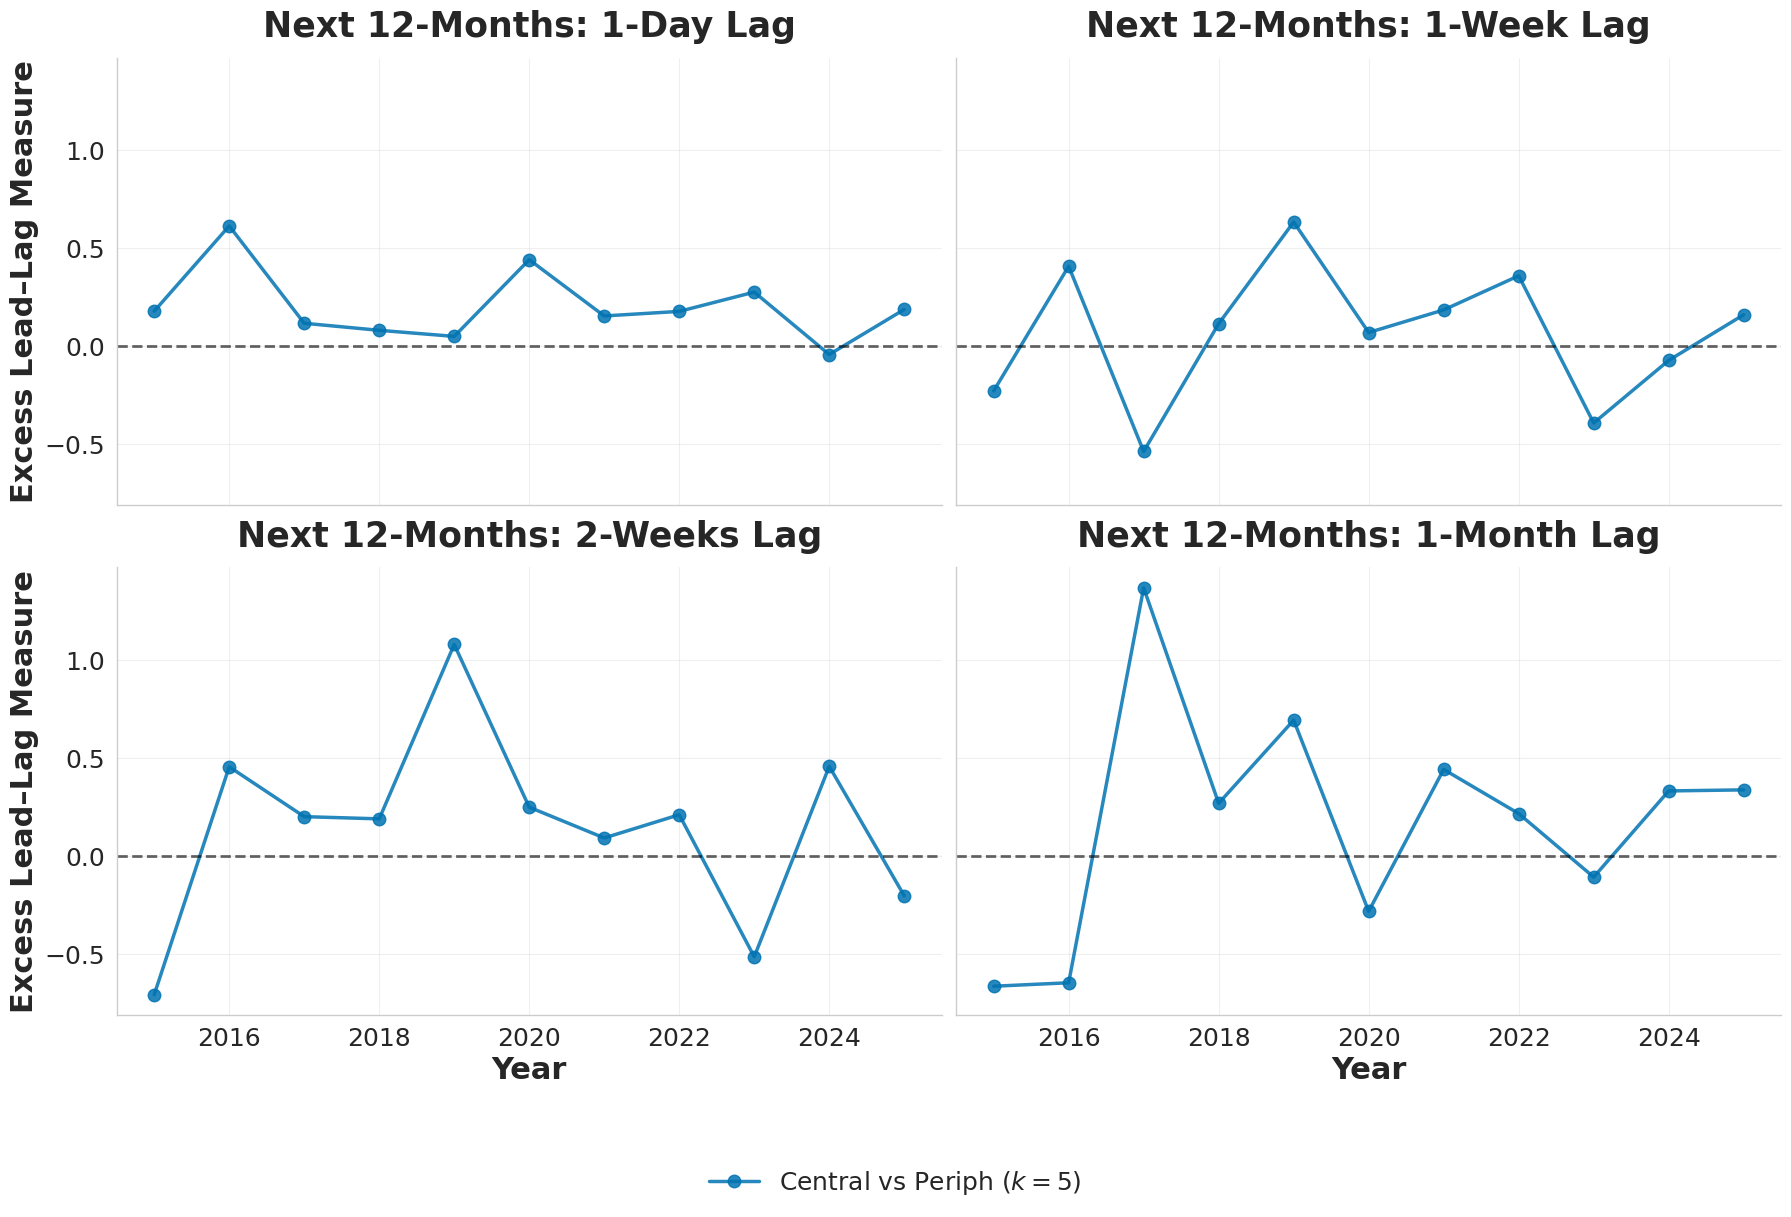

In [5]:
out_of_sample_lead_lag(n_months=12)

In [15]:
def lead_lag_10_years_oos(network_year=2015):
    centralities = ["central", "peripheral"]
    # k_values já deve estar definido globalmente, ex: k_values = [1, 10, 30]
    
    # 1. Carregar a rede fixa do ano selecionado (ex: 2015)
    base_portfolios = {}
    for centrality in centralities:
        for k in k_values:
            path_csv = f"../../data/06_portfolios/{centrality}_{network_year}_{k}.csv"
            base_portfolios[f"{centrality}_{k}"] = pd.read_csv(path_csv, index_col="Date").columns.tolist()
            
    # 2. Carregar os retornos de TODOS os próximos anos de uma só vez
    df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
    # Filtra apenas datas estritamente maiores que o ano da rede (Out-of-Sample)
    df_ret_oos = df_ret_full[df_ret_full.index.year > network_year].copy()
    
    # Carregar metadados para Value Weighting usando o ano base da rede
    df_mcap = pd.read_csv("../../data/02_clean/METADADOS_ATUALIZADO - Sheet1.csv")
    mcap_col = f"mcap_{network_year}"
    if mcap_col not in df_mcap.columns:
        mcap_col = [c for c in df_mcap.columns if "mcap_" in c][-1]
        
    daily_returns = {}
    weekly_returns = {}
    weekly2_returns = {}
    monthly_returns = {}
    
    # 3. Calcular Retornos para o bloco inteiro de 10 anos
    for centrality in centralities:
        for k in k_values:
            name = f"{centrality}_{k}"
            cols = base_portfolios[name]
            
            # Pega as colunas do portfólio que existem no parquet
            valid_cols = [c for c in cols if c in df_ret_oos.columns]
            portfolio = df_ret_oos[valid_cols]
            
            log_returns = np.log1p(portfolio)
            
            # Pesos pelo Market Cap
            tickers = portfolio.columns.tolist()
            mcaps = df_mcap[df_mcap["Ticker"].isin(tickers)][["Ticker", mcap_col]].copy()
            # CORREÇÃO: Tratamento do formato brasileiro
            mcaps[mcap_col] = pd.to_numeric(
                mcaps[mcap_col].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
                errors='coerce'
            ).fillna(0)

            weights_df = pd.DataFrame({"Ticker": tickers}).merge(mcaps, on="Ticker", how="left").fillna(0)
            weights = weights_df[mcap_col].values
            
            if weights.sum() == 0:
                weights = np.ones(len(weights)) / len(weights)
            else:
                weights = weights / weights.sum()
                
            # Retornos Value-Weighted da janela de 10 anos inteira
            vw_returns = (log_returns * weights).sum(axis=1)
            
            daily_returns[name] = vw_returns
            weekly_returns[name] = (log_returns.resample("W-FRI").sum() * weights).sum(axis=1)
            weekly2_returns[name] = (log_returns.resample("2W-FRI").sum() * weights).sum(axis=1)
            monthly_returns[name] = (log_returns.resample("ME").sum() * weights).sum(axis=1)

    # 4. Construir o Dataframe de Lead-Lag
    results = []
    for k in k_values:
        # Pares de retornos ao longo dos 10 anos inteiros
        pairs = [
            (daily_returns[f"peripheral_{k}"], daily_returns[f"central_{k}"]),
            (weekly_returns[f"peripheral_{k}"], weekly_returns[f"central_{k}"]),
            (weekly2_returns[f"peripheral_{k}"], weekly2_returns[f"central_{k}"]),
            (monthly_returns[f"peripheral_{k}"], monthly_returns[f"central_{k}"])
        ]

        matrix = []
        for R_peri, R_cent in pairs:
            X = pd.concat([R_peri, R_cent], axis=1).dropna()
            X.columns = ["Peripheral", "Central"]
            
            max_lag = 5
            valid_lags = [l for l in range(1, max_lag + 1) if len(X) >= l + 4]
            if not valid_lags:
                matrix.append(float('nan'))
                continue
                
            total_lead_lag = 0
            for l in valid_lags:
                # Aqui o X é o dataframe gigante de 10 anos!
                acm = autocorrelation_matrix(X, lag=l)
                lag_matrix = acm - acm.T
                # CORREÇÃO: Índice [0, 1] ajustado
                total_lead_lag += lag_matrix[0, 1]
            
            matrix.append(total_lead_lag)

        # Adicionar o resultado desse K
        results.append([f"k={k}"] + matrix)
        
    df_results = pd.DataFrame(
        results, 
        columns=["k_value", "cp1d", "cp1w", "cp2w", "cp1m"]
    )
    
    return df_results

In [16]:
df_oos_10_anos = lead_lag_10_years_oos(network_year=2015)
display(df_oos_10_anos)

,k_value,cp1d,cp1w,cp2w,cp1m
0,k=1,-0.127186,-0.028187,-0.090273,-0.052999
1,k=10,-0.123714,0.096804,0.092465,0.127551
2,k=30,-0.159715,-0.042390,-0.041135,-0.028452
